In [15]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time



In [16]:
# Define the target URL for the local car marketplace
url = "https://turbo.az/autos"

# Send an HTTP GET request to the website
response = requests.get(url)

# Check the response status code (200 means connection successful)
print("Status Code:", response.status_code)

Status Code: 403


In [17]:
# Define headers to mimic a real Google Chrome browser session
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# Define the target URL
url = "https://turbo.az/autos"

# Send the request again, this time passing the browser headers
response = requests.get(url, headers=headers)

# Check the status code again (Looking for 200 now)
print("New Status Code:", response.status_code)

New Status Code: 200


In [18]:
# Parse the raw HTML content using BeautifulSoup
soup = BeautifulSoup(response.content, "html.parser")

# Test if we can extract the page title to confirm successful parsing
print("Page Title:", soup.title.text)

Page Title: Turbo.Az - Avtomobilləri burada seçirlər


In [19]:
# Find all car listings on the page (Turbo.az uses 'products-i' class for each car)
car_listings = soup.find_all("div", class_="products-i")

# Count how many cars we found on this single page
print("Total cars found on this page:", len(car_listings))

Total cars found on this page: 36


In [20]:
import time

# Create an empty list to store all our scraped data from all pages
car_data = []

# Loop through pages (e.g., from page 1 to 35)
for page in range(1, 36):
    print(f"Scraping page {page}...")
    
    # Update the URL for each page dynamically
    url = f"https://turbo.az/autos?page={page}"
    response = requests.get(url, headers=headers)
    soup = BeautifulSoup(response.text, 'html.parser')
    
    # Find all car listings on the current page
    car_listings = soup.find_all("div", class_="products-i")
    
    # Loop through the cars found on this specific page
    for car in car_listings:
        try:
            price = car.find("div", class_="products-i__price").text.strip()
            name = car.find("div", class_="products-i__name").text.strip()
            attributes = car.find("div", class_="products-i__attributes").text.strip()
            
            car_data.append({
                "Car Name": name,
                "Price": price,
                "Attributes": attributes
            })
        except AttributeError:
            continue
            
    # Pause for 1 second between pages to avoid getting blocked by the website
    time.sleep(1)

# Convert all collected data into a Pandas DataFrame
df = pd.DataFrame(car_data)
print("Total cars scraped from all pages:", len(df))

Scraping page 1...
Scraping page 2...
Scraping page 3...
Scraping page 4...
Scraping page 5...
Scraping page 6...
Scraping page 7...
Scraping page 8...
Scraping page 9...
Scraping page 10...
Scraping page 11...
Scraping page 12...
Scraping page 13...
Scraping page 14...
Scraping page 15...
Scraping page 16...
Scraping page 17...
Scraping page 18...
Scraping page 19...
Scraping page 20...
Scraping page 21...
Scraping page 22...
Scraping page 23...
Scraping page 24...
Scraping page 25...
Scraping page 26...
Scraping page 27...
Scraping page 28...
Scraping page 29...
Scraping page 30...
Scraping page 31...
Scraping page 32...
Scraping page 33...
Scraping page 34...
Scraping page 35...
Total cars scraped from all pages: 1260


In [21]:
# Function to smartly extract Year, Engine, and Mileage from the messy Attributes column
def clean_car_attributes(attr_text):
    year, engine, mileage = None, None, None
    
    # Split the text by commas
    parts = [p.strip() for p in str(attr_text).split(',')]
    
    for part in parts:
        if 'km' in part:
            mileage = part  # Extract mileage (e.g., "14 088 km")
        elif 'L' in part:
            engine = part   # Extract engine volume (e.g., "1.5 L")
        elif part.isdigit() and len(part) == 4:
            year = part     # Extract 4-digit production year (e.g., "2025")
            
    return pd.Series([year, engine, mileage])

# Apply the function and create 3 new columns in our DataFrame
df[['Year', 'Engine', 'Mileage']] = df['Attributes'].apply(clean_car_attributes)

# Drop the old messy 'Attributes' column since we don't need it anymore
df = df.drop(columns=['Attributes'])

# Display the first 10 rows of our newly structured, clean dataset
print(df.head(10))

                 Car Name      Price  Year Engine     Mileage
0        JMC Grand Avenue   63 900 ₼  2025  2.3 L        0 km
1                  BMW M5   54 400 ₼  2012  4.4 L  108 000 km
2  Audi RS Q8 Performance  308 646 ₼  2026  4.0 L        0 km
3                KAIYI X7   37 900 ₼  2025  1.6 L        0 km
4        Can-Am Spyder RS   18 000 ₼  2010  0.9 L    3 661 km
5          Hyundai Sonata   24 000 ₼  2014  2.0 L  216 000 km
6     Ford Mustang Mach-E   40 800 ₼  2021   None   92 000 km
7          Hyundai Sonata   39 000 ₼  2021  2.0 L   68 000 km
8          Hyundai Sonata   26 700 ₼  2018  2.0 L   81 765 km
9        Hyundai Santa Fe   47 800 ₼  2018  2.0 L  115 000 km


In [22]:
# --- ADVANCED CLEANING: CONVERTING TEXT COLUMNS TO NUMBERS ---

# 1. Clean 'Price' column: Remove spaces and currency symbols, then convert to Integer
df['Price'] = df['Price'].str.replace(r'\s+', '', regex=True) # Removes all spaces
df['Price'] = df['Price'].str.replace('AZN', '', case=False)  # Removes AZN if exists
df['Price'] = df['Price'].str.replace('₼', '')               # Removes ₼ symbol
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')    # Convert to number (Integer)

# 2. Clean 'Mileage' column: Remove spaces and 'km', then convert to Integer
df['Mileage'] = df['Mileage'].str.replace(r'\s+', '', regex=True) # Removes spaces
df['Mileage'] = df['Mileage'].str.replace('km', '', case=False)   # Removes 'km' text
df['Mileage'] = pd.to_numeric(df['Mileage'], errors='coerce')    # Convert to number (Integer)

# 3. Clean 'Engine' column: Remove 'L', then convert to Float (Decimal number)
df['Engine'] = df['Engine'].str.replace('L', '', case=False).str.strip() # Removes 'L'
df['Engine'] = pd.to_numeric(df['Engine'], errors='coerce')              # Convert to Float (e.g., 2.0)

# Check the structural data types of our columns now
print("--- Column Data Types ---")
print(df.dtypes)

# Display the first 10 rows to see the clean numbers
print("\n--- Cleaned Dataset ---")
print(df.head(10))

--- Column Data Types ---
Car Name     object
Price         int64
Year         object
Engine      float64
Mileage       int64
dtype: object

--- Cleaned Dataset ---
                 Car Name   Price  Year  Engine  Mileage
0        JMC Grand Avenue   63900  2025     2.3        0
1                  BMW M5   54400  2012     4.4   108000
2  Audi RS Q8 Performance  308646  2026     4.0        0
3                KAIYI X7   37900  2025     1.6        0
4        Can-Am Spyder RS   18000  2010     0.9     3661
5          Hyundai Sonata   24000  2014     2.0   216000
6     Ford Mustang Mach-E   40800  2021     NaN    92000
7          Hyundai Sonata   39000  2021     2.0    68000
8          Hyundai Sonata   26700  2018     2.0    81765
9        Hyundai Santa Fe   47800  2018     2.0   115000


In [23]:
# --- STEP 4: SAVE TO COMPUTER (Datanı Kompüterə Save Edirik) ---
df.to_csv("turbo_az_clean_data.csv", index=False)
print("Data officially SAVED to 'turbo_az_clean_data.csv'!\n")


# --- STEP 5: FINAL PYTHON DATA ANALYSIS (Ümumi və İlə Görə Analiz) ---
print("==============================================")
print("     TURBO.AZ DATA ANALYSIS SUMMARY           ")
print("==============================================")

# Ümumi göstəricilər
print(f"• Average Car Price   : {df['Price'].mean():.2f} AZN")
print(f"• Most Expensive Car  : {df['Price'].max():.2f} AZN")
print(f"• Cheapest Car        : {df['Price'].min():.2f} AZN")
print(f"• Average Mileage     : {df['Mileage'].mean():.2f} km")
print(f"• Average Engine Vol. : {df['Engine'].mean():.2f} L")
print("==============================================\n")

print("==============================================")
print("     YEARLY CAR MARKET ANALYSIS (İlə Görə)    ")
print("==============================================")

# 'Year' sütununu rəqəmə çevirib, ilə görə qruplaşdırırıq
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df_yearly = df.dropna(subset=['Year'])

yearly_analysis = df_yearly.groupby('Year')[['Price', 'Mileage']].mean().sort_index().round(2)
print(yearly_analysis)
print("==============================================")

Data officially SAVED to 'turbo_az_clean_data.csv'!

     TURBO.AZ DATA ANALYSIS SUMMARY           
• Average Car Price   : 38063.44 AZN
• Most Expensive Car  : 476000.00 AZN
• Cheapest Car        : 2400.00 AZN
• Average Mileage     : 135645.35 km
• Average Engine Vol. : 2.08 L

     YEARLY CAR MARKET ANALYSIS (İlə Görə)    
         Price    Mileage
Year                     
1985   6500.00  155032.00
1990   2600.00  126660.50
1991   5000.00  400000.00
1992   4675.00  362500.00
1993   7800.00  362402.50
1994  18500.00  220000.00
1995   5290.00  251470.60
1996   5950.00  336377.75
1997   6436.00  374247.60
1998   8166.67  302234.67
1999   9785.00  345804.10
2000  11881.82  289322.45
2001  10260.29  314104.14
2002  12569.23  255318.31
2003  10491.00  225527.60
2004  17823.30  257194.70
2005  13206.25  197565.25
2006  16596.15  226945.23
2007  15552.27  249200.45
2008  16841.03  288813.03
2009  22496.00  274300.32
2010  20934.00  234956.96
2011  22570.23  264098.81
2012  27570.58  221611.

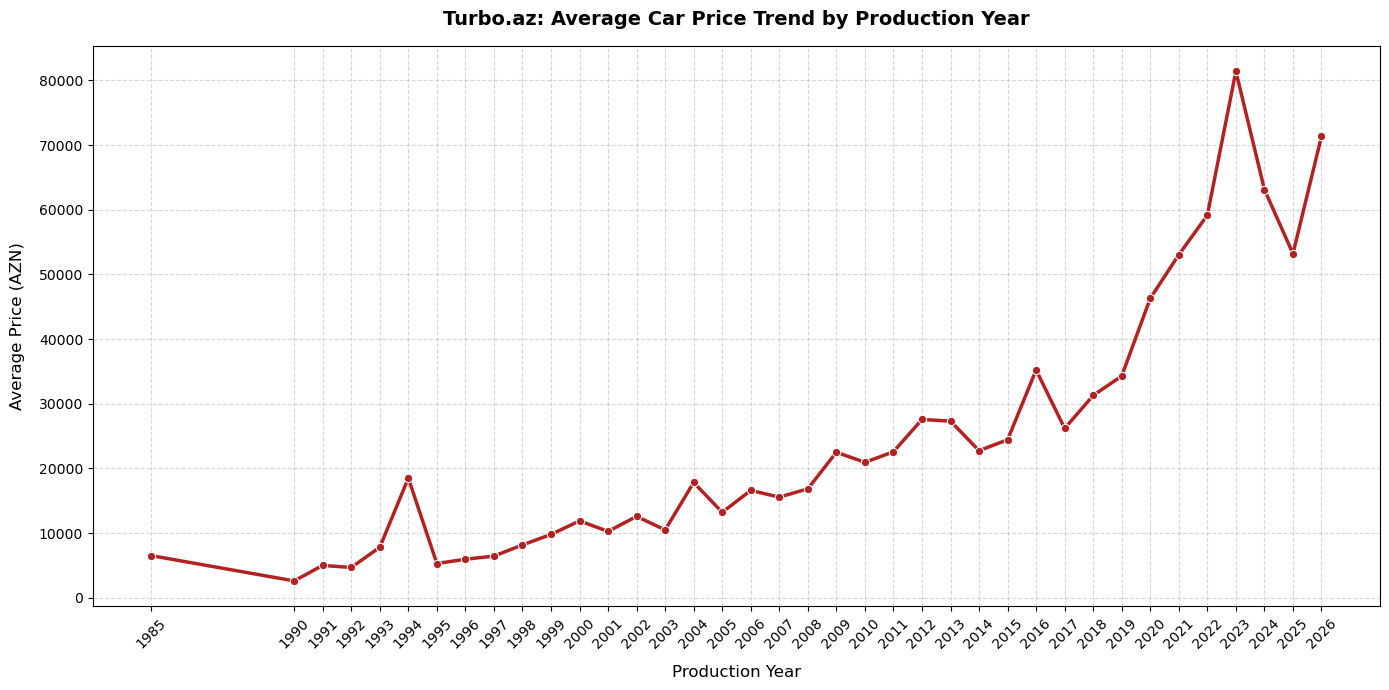

In [25]:
# --- STEP 6: ADVANCED DATA VISUALIZATION (English Version) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure Year is treated as integer and drop missing ones for plotting
df_yearly = df.dropna(subset=['Year']).copy()
df_yearly['Year'] = df_yearly['Year'].astype(int)

# Group by Year and get average price
yearly_price = df_yearly.groupby('Year')['Price'].mean().reset_index()

# Set up the plot size
plt.figure(figsize=(14, 7))

# Draw the line plot
sns.lineplot(data=yearly_price, x='Year', y='Price', marker='o', color='firebrick', linewidth=2.5)

# --- Format the years to be shown one by one and rotate 45 degrees ---
unique_years = sorted(yearly_price['Year'].unique())
plt.xticks(unique_years, rotation=45, fontsize=10)
plt.yticks(fontsize=10)

# English titles and labels for international portfolio
plt.title('Turbo.az: Average Car Price Trend by Production Year', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Production Year', fontsize=12, labelpad=10)
plt.ylabel('Average Price (AZN)', fontsize=12, labelpad=10)

# Add clear grid lines to the background
plt.grid(True, linestyle='--', alpha=0.5)

# Prevent edge cutting
plt.tight_layout()

# Show the plot on the screen
plt.show()

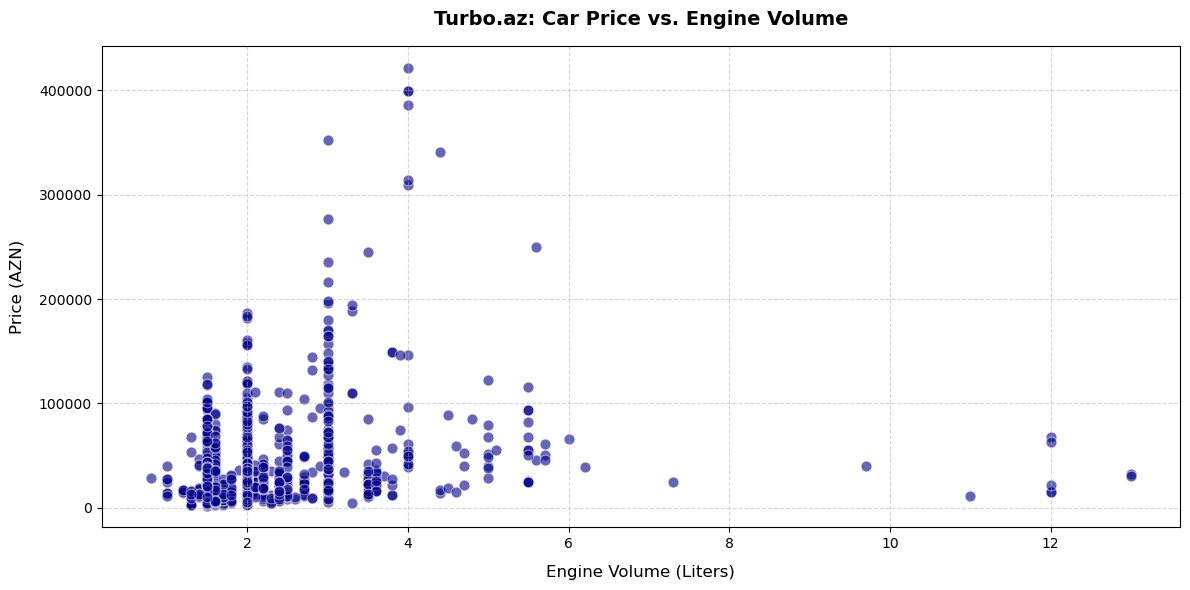

In [17]:
# --- STEP 7: SCATTER PLOT - ENGINE VOLUME VS PRICE (English Version) ---

# Drop missing values for Engine and Price just for this visualization
df_scatter = df.dropna(subset=['Engine', 'Price']).copy()

# Set up the plot size
plt.figure(figsize=(12, 6))

# Draw the scatter plot using Seaborn
# alpha=0.6 makes dots slightly transparent so we can see where they density is
sns.scatterplot(data=df_scatter, x='Engine', y='Price', alpha=0.6, color='darkblue', edgecolor='w', s=60)

# English titles and labels
plt.title('Turbo.az: Car Price vs. Engine Volume', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Engine Volume (Liters)', fontsize=12, labelpad=10)
plt.ylabel('Price (AZN)', fontsize=12, labelpad=10)

# Add grid lines for easier reading
plt.grid(True, linestyle='--', alpha=0.5)

# Tight layout to avoid cutting off labels
plt.tight_layout()

# Show the plot
plt.show()

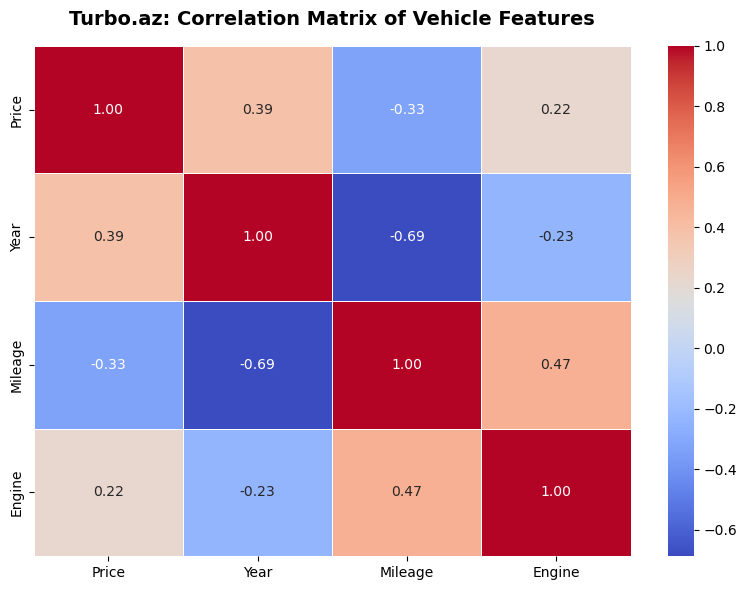

In [18]:
# --- STEP 8: CORRELATION HEATMAP (English Version) ---

# Select only the numerical columns for correlation analysis
numerical_cols = ['Price', 'Year', 'Mileage', 'Engine']
corr_matrix = df[numerical_cols].corr()

# Set up the plot size
plt.figure(figsize=(8, 6))

# Create a heatmap using Seaborn
# annot=True puts the numbers inside the squares
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# English titles
plt.title('Turbo.az: Correlation Matrix of Vehicle Features', fontsize=14, fontweight='bold', pad=15)

# Tight layout
plt.tight_layout()

# Show the plot
plt.show()

In [28]:
# --- STEP 9: TOP BRANDS IN OUR DATA ---

# Extract the brand name (first word of 'Car Name')
df['Brand'] = df['Car Name'].apply(lambda x: str(x).split()[0] if pd.notnull(x) else None)

# Count how many cars per brand and show Top 5
print("==============================================")
print("       TOP 5 CAR BRANDS IN OUR DATASET        ")
print("==============================================")
print(df['Brand'].value_counts().head(5))
print("==============================================")

       TOP 5 CAR BRANDS IN OUR DATASET        
Brand
Hyundai     139
Mercedes    130
Toyota      110
Kia         101
Changan      91
Name: count, dtype: int64


In [29]:
# --- STEP 11.1: FIND SPECIFIC TOYOTA MODELS ---
toyota_df = df[df['Brand'].str.lower() == 'toyota'].copy()

print("==============================================")
print("     AVAILABLE TOYOTA MODELS IN DATASET      ")
print("==============================================")
# Siyahıda ilk iki sözü götürürük ki, model tam görünsün (örnək: Toyota Prius)
toyota_df['Model_Full'] = toyota_df['Car Name'].apply(lambda x: " ".join(str(x).split()[:2]))
print(toyota_df['Model_Full'].value_counts())
print("==============================================")

     AVAILABLE TOYOTA MODELS IN DATASET      
Model_Full
Toyota Corolla        25
Toyota RAV4           21
Toyota Camry          18
Toyota Land           15
Toyota Prius          13
Toyota Aqua            4
Toyota Frontlander     3
Toyota bZ4X            3
Toyota Highlander      3
Toyota bZ3X            1
Toyota Yaris           1
Toyota Auris           1
Toyota FJ              1
Toyota Harrier         1
Name: count, dtype: int64


In [30]:
# --- STEP 12: SPECIFIC MODEL DEEP DIVE - TOYOTA PRIUS (English Version) ---

# Filter specifically for Toyota Prius (case-insensitive)
prius_df = df[df['Car Name'].str.lower().str.contains('prius', na=False)].copy()

print("\n==========================================================================")
print(f"               DETAILED MARKET ANALYSIS FOR: TOYOTA PRIUS                ")
print("==========================================================================")
print(f"Total Prius found in our dataset: {len(prius_df)} cars\n")

# Select specific columns to display cleanly
prius_table = prius_df[['Car Name', 'Year', 'Price', 'Mileage', 'Engine']].sort_values(by='Year', ascending=False)

# Print the clean table row by row
print(prius_table.to_string(index=False))
print("==========================================================================\n")

# Quick statistics for Prius only
if len(prius_df) > 0:
    print("--- QUICK PRIUS STATS ---")
    print(f"• Average Prius Price   : {prius_df['Price'].mean():.2f} AZN")
    print(f"• Lowest Prius Price    : {prius_df['Price'].min():.2f} AZN")
    print(f"• Highest Prius Price   : {prius_df['Price'].max():.2f} AZN")
    print(f"• Average Prius Mileage : {prius_df['Mileage'].mean():.2f} km")
    print("==========================================================================")


               DETAILED MARKET ANALYSIS FOR: TOYOTA PRIUS                
Total Prius found in our dataset: 13 cars

    Car Name  Year  Price  Mileage  Engine
Toyota Prius  2012  17900   344400     1.8
Toyota Prius  2011  15500   285000     1.8
Toyota Prius  2010  15200   301000     1.8
Toyota Prius  2010  12500   298000     1.8
Toyota Prius  2009  17900   320088     1.8
Toyota Prius  2008  11600   356999     1.5
Toyota Prius  2008  12800   349000     1.5
Toyota Prius  2008  12000   424867     1.5
Toyota Prius  2007  11800   262114     1.5
Toyota Prius  2007  11300   233355     1.5
Toyota Prius  2007  11600   405000     1.5
Toyota Prius  2007  12800   353470     1.5
Toyota Prius  2005  10700   350000     1.5

--- QUICK PRIUS STATS ---
• Average Prius Price   : 13353.85 AZN
• Lowest Prius Price    : 10700.00 AZN
• Highest Prius Price   : 17900.00 AZN
• Average Prius Mileage : 329484.08 km


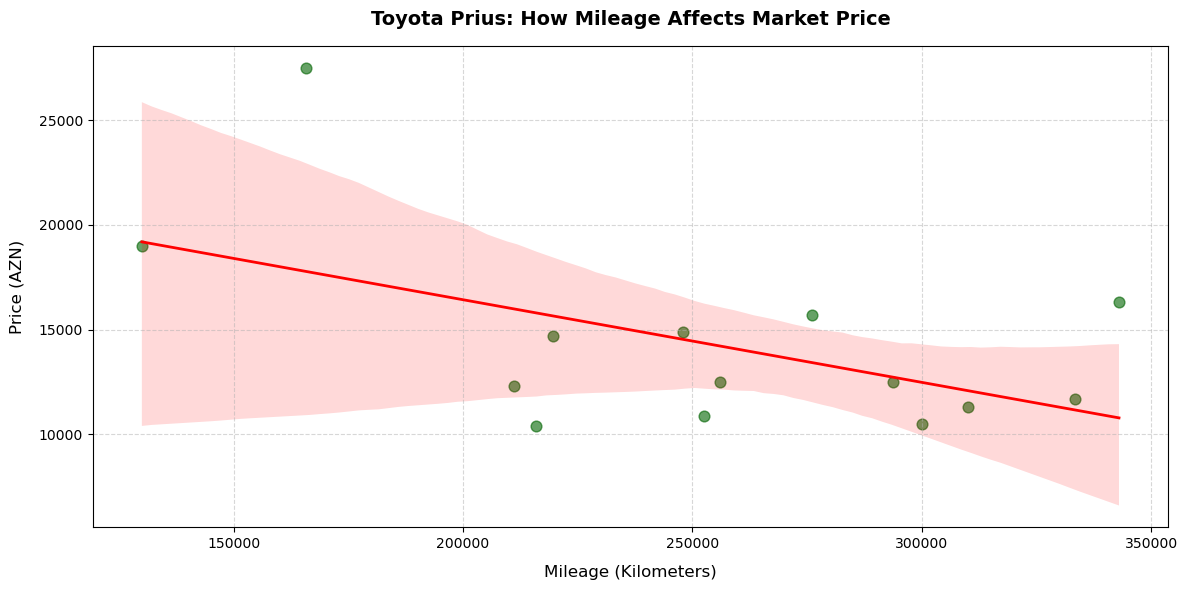

In [25]:
# --- STEP 13: PRIUS SPECIAL - PRICE VS MILEAGE SCATTER PLOT (English Version) ---
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plot size
plt.figure(figsize=(12, 6))

# Create a scatter plot with a trend line (reg line) for Toyota Prius
sns.regplot(data=prius_df, x='Mileage', y='Price', color='darkgreen', 
            scatter_kws={'alpha':0.6, 's':60}, line_kws={'color':'red', 'linewidth':2})

# English titles and labels
plt.title('Toyota Prius: How Mileage Affects Market Price', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Mileage (Kilometers)', fontsize=12, labelpad=10)
plt.ylabel('Price (AZN)', fontsize=12, labelpad=10)

# Add grid lines
plt.grid(True, linestyle='--', alpha=0.5)

# Tight layout
plt.tight_layout()

# Show the plot
plt.show()

In [26]:
# --- STEP 14: PREDICTIVE ANALYTICS - PRIUS PRICE PREDICTION ---
import numpy as np

print("\n==========================================================================")
print("             PREDICTIVE ANALYTICS: PRIUS PRICE VALUATION                  ")
print("==========================================================================")

# Simple Linear Regression math to find the trend line equation: Price = m * Mileage + c
# Drop rows with NaN just in case
prius_clean = prius_df.dropna(subset=['Mileage', 'Price'])

if len(prius_clean) > 5:
    x = prius_clean['Mileage']
    y = prius_clean['Price']
    
    # Calculate slopes
    m, c = np.polyfit(x, y, 1)
    
    print("Based on our database, the AI learned the pricing logic of the market.")
    print("Let's predict the market value of a Prius with specific mileages:\n")
    
    # Test cases for prediction
    test_mileages = [50000, 150000, 250000]
    
    for mil in test_mileages:
        predicted_price = m * mil + c
        print(f"💡 Predicted Price for a Prius with {mil:,} km mileage: {predicted_price:.2f} AZN")
        
    print("\n*Note: This formula automatically calculates how much value a Prius loses per km.")
    print(f"📉 Every 10,000 km of driving drops the price by approximately {abs(m * 10000):.2f} AZN!")
else:
    print("Not enough Prius data rows to run the predictive model.")
print("==========================================================================\n")


             PREDICTIVE ANALYTICS: PRIUS PRICE VALUATION                  
Based on our database, the AI learned the pricing logic of the market.
Let's predict the market value of a Prius with specific mileages:

💡 Predicted Price for a Prius with 50,000 km mileage: 22342.15 AZN
💡 Predicted Price for a Prius with 150,000 km mileage: 18396.77 AZN
💡 Predicted Price for a Prius with 250,000 km mileage: 14451.39 AZN

*Note: This formula automatically calculates how much value a Prius loses per km.
📉 Every 10,000 km of driving drops the price by approximately 394.54 AZN!

